In [236]:
import pandas as pd

In [237]:
df = pd.read_csv("data/titanic.csv")

In [238]:
df.shape # Zeilen, Spalten
list(df.columns) # Spaltennamen als Liste
df.head() # die ersten 5
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## Kennzahlen

In [239]:
df[ ["Age", "Fare"] ].describe().round(2) # beschreibende Statistik 

,Age,Fare
count,714.00,891.00
mean,29.70,32.20
std,14.53,49.69
min,0.42,0.00
25%,20.12,7.91
50%,28.00,14.45
75%,38.00,31.00
max,80.00,512.33


In [240]:
# Fehlende Werte finden 

df1 = df.isna().sum().sort_values(ascending=False).head(3) # ascending -> aufsteigend,
# nach Anzahl absteigend sortiert 

# Anteil Fehlende Werte in % 
df2 = (df.isna().mean().sort_values(ascending=False).head(3)*100).round(2) # ascending -> aufsteigend,

pd.concat([df1,df2], axis=1) # spaltenweise Concatenation der Datensätze 

,0,1
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [241]:
list(df.columns)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [242]:
df_cur = df[
    [
'PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
# 'Cabin',
 'Embarked'
 ]
]

In [243]:
# Nicht-kritische Löschung 
# TODO alle Zeilen löschen wo "Embarked" NaN ist (fehlt)
# .isna() ist boolesche Maske 

maske = ~(df_cur["Embarked"].isna())
df_cur = df_cur[maske] # alles was nicht NaN ist kommt rein 
df_cur.shape

(889, 11)

In [244]:
# Age 
maske = df_cur["Age"].isna()

# Flagging -> neue Spalte, wo wir markieren, wo das Alter fehlt 
df_cur["Age_missing"] = maske.astype(int) # Bool nach int 

# Auffüllen mit Median
df_cur["Age"] = df_cur["Age"].fillna(df_cur["Age"].median())

In [245]:
# lineare Korrelation 
df.corr(numeric_only=True)["Survived"].round(2)

PassengerId   -0.01
Survived       1.00
Pclass        -0.34
Age           -0.08
SibSp         -0.04
Parch          0.08
Fare           0.26
Name: Survived, dtype: float64

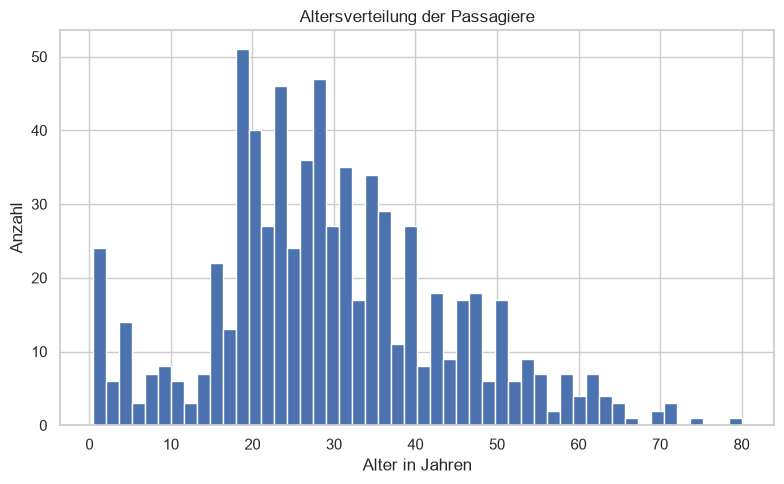

In [246]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))   # Figure = Blatt, Axes = Diagramm

ax.hist(df["Age"].dropna(), bins=50)

ax.set_title("Altersverteilung der Passagiere")
ax.set_xlabel("Alter in Jahren")
ax.set_ylabel("Anzahl")

fig.tight_layout()
fig.savefig("alter_histogramm.png", dpi=150)
#plt.show()

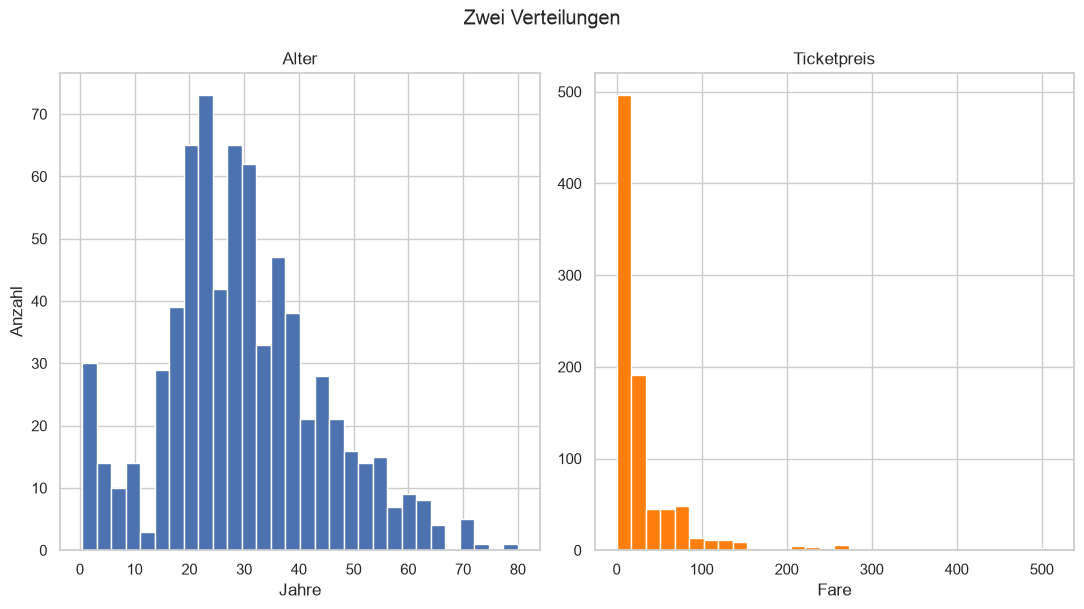

In [247]:
fig, axes = plt.subplots(
    1, 2, figsize=(11, 6.2))

axes[0].hist(df["Age"].dropna(),
             bins=30)
axes[0].set_title("Alter")
axes[0].set_xlabel("Jahre")
axes[0].set_ylabel("Anzahl")

axes[1].hist(df["Fare"], bins=30,
             color="#ff7f0e")
axes[1].set_title("Ticketpreis")
axes[1].set_xlabel("Fare")

fig.suptitle("Zwei Verteilungen")
fig.tight_layout()

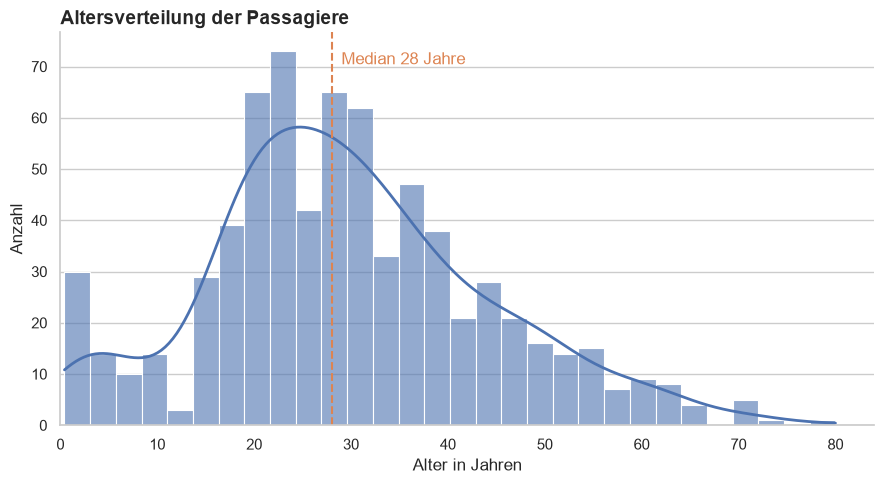

In [248]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")   # ruhiger Hintergrund, feines Gitter

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x="Age",
             bins=30, kde=True,
             color="#4C72B0", alpha=0.6,          # gedämpftes Blau, halbtransparent
             edgecolor="white", linewidth=0.8,    # weiße Balkenränder trennen die Bins
             line_kws={"linewidth": 2},           # KDE-Linie etwas kräftiger
             ax=ax)

# Median als Referenzlinie mit Beschriftung
median = df["Age"].median()
ax.axvline(median, color="#DD8452", linestyle="--", linewidth=1.5)
ax.text(median + 1, ax.get_ylim()[1] * 0.95, f"Median {median:.0f} Jahre",
        color="#DD8452", va="top")

ax.set_title("Altersverteilung der Passagiere", loc="left", fontsize=14, weight="bold")
ax.set_xlabel("Alter in Jahren")
ax.set_ylabel("Anzahl")
ax.set_xlim(0, None)
sns.despine(ax=ax)          # obere und rechte Achsenlinie weg
ax.grid(axis="x", visible=False)   # Gitter nur waagerecht

fig.tight_layout()


Text(0.5, 1.0, 'Korrelationsmatrix')

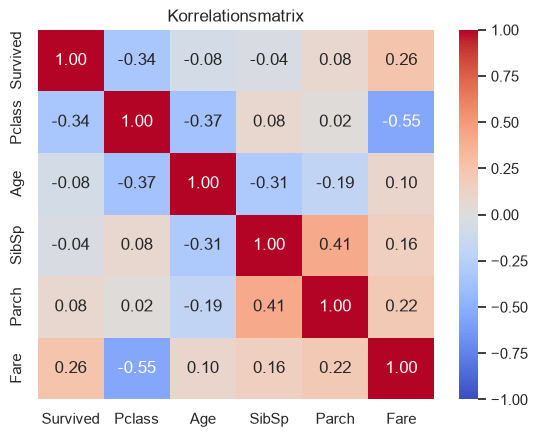

In [249]:
spalten = ["Survived", "Pclass", "Age",
           "SibSp", "Parch", "Fare"]
corr = df[spalten].corr()

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Korrelationsmatrix")

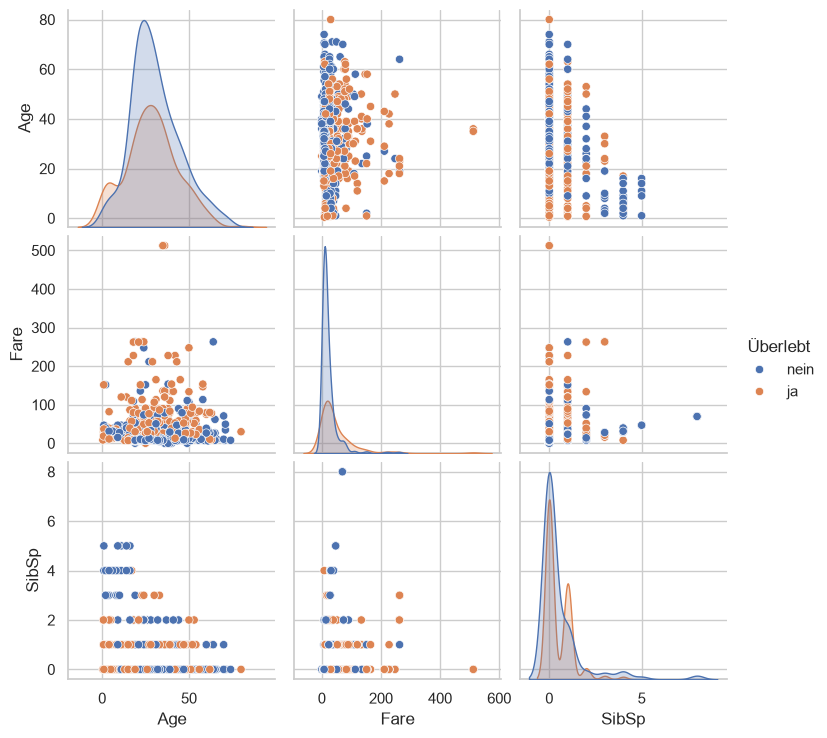

In [250]:
df["Überlebt"] = df["Survived"].map(
    {0: "nein", 1: "ja"})
sns.pairplot(
    df,
    vars=["Age", "Fare", "SibSp"],
    hue="Überlebt",
)

# Vorhersage "Survived"

In [251]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [252]:
OneHotEncoder().fit_transform((df_cur[["Sex"]])).toarray()

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(889, 2))

In [253]:
df_cur_v1 = df_cur[[ "Age", "Fare", "SibSp", "Parch"]]
X1 = df_cur_v1
y = df_cur["Survived"]

In [254]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size= 0.2, random_state=1)
scaler = StandardScaler()
X1_train_s = scaler.fit_transform(X1_train) # Mittelwert & Standartabweichung lernen 
X1_test_s = scaler.transform(X1_test)

In [255]:
model = LogisticRegression(max_iter=1000).fit(X1_train_s, y1_train) # Anzahl der Optimierungsschritte 
acc = model.score(X1_test_s, y1_test) # Genauigkeit
print("Genauigkeit:", round(acc*100,3), "%")

Genauigkeit: 64.607 %


In [256]:
model = KNeighborsClassifier(n_neighbors=5).fit(X1_train_s, y1_train) # Anzahl der Optimierungsschritte 
acc = model.score(X1_test_s, y1_test) # Genauigkeit
print("Genauigkeit:", round(acc*100,3), "%")

Genauigkeit: 70.787 %


In [257]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1).fit(X1_train_s, y1_train) # Anzahl der Optimierungsschritte 
acc = model.score(X1_test_s, y1_test) # Genauigkeit
print("Genauigkeit:", round(acc*100,3), "%")

Genauigkeit: 70.225 %


In [258]:
num_cols = ["Age", "Fare", "SibSp", "Parch"]
cat_cols = ["Pclass", "Sex", "Embarked"]
X = df[num_cols + cat_cols]  # kein dropna, kein fillna: die Rohdaten bleiben, wie die sind 
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1, stratify=y) 


In [259]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
# Pipelines 

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler()), 
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("scaler", OneHotEncoder(handle_unknown="ignore")), # handle_unknown -> unbekannte Kategorie ignorieren
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols), 
    ("cat", categorical_pipe, cat_cols)
])

In [ ]:
# vollständige Pipeline mit der Vorhersagemethode zusammen 

clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000)), # baseline 
    
])

clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

In [261]:
clf.fit(X_train, y_train) # Pipeline anwenden = Vorbereiten und Modell Lernen 
acc = clf.score(X_test, y_test) # Genauigkeit
print("Genauigkeit:", round(acc*100,3), "%")

Genauigkeit: 79.888 %
